### 생선의 길이를 사용하여 무게를 예측 

In [1]:
import numpy as np

In [2]:
fish_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
fish_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

In [3]:
# 크기
print(fish_length.shape)
print(fish_weight.shape)

(56,)
(56,)


In [4]:
print(np.mean(fish_length))
print(np.median(fish_length))
print(np.mean(fish_weight))
print(np.median(fish_weight))

27.892857142857142
25.3
382.23928571428576
207.5


In [5]:
# 상관관계
np.corrcoef(fish_length, fish_weight)

array([[1.        , 0.95865587],
       [0.95865587, 1.        ]])

### 길이와 무게를 산포도로 표현

In [6]:
import matplotlib.pyplot as plt

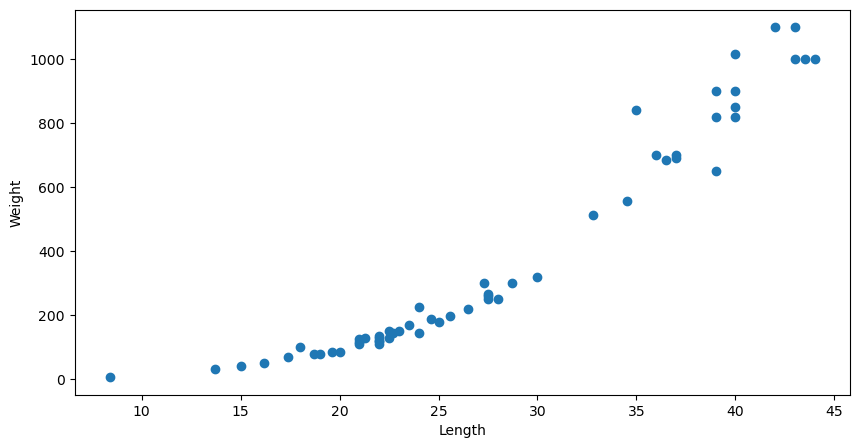

In [7]:
plt.figure(figsize=(10, 5))
plt.scatter(
    fish_length,
    fish_weight
)
plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()

#### Train Set과 Test Set의 분리

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
train_input, test_input, train_target, test_target = \
                                train_test_split(
                                    fish_length,
                                    fish_weight,
                                    random_state=42
                                )

> 분류문제가 아니고 회귀문제이면 train_test분리시 stratify는 사용하지 않는다. 

In [10]:
# 확인
print(train_input.shape)
print(test_input.shape)
print(train_target.shape)
print(test_target.shape)

(42,)
(14,)
(42,)
(14,)


In [11]:
train_input

array([19.6, 22. , 18.7, 17.4, 36. , 25. , 40. , 39. , 43. , 22. , 20. ,
       22. , 24. , 27.5, 43. , 40. , 24. , 21. , 27.5, 40. , 32.8, 26.5,
       36.5, 13.7, 22.7, 15. , 37. , 35. , 28.7, 23.5, 39. , 21. , 23. ,
       22. , 44. , 22.5, 19. , 37. , 22. , 25.6, 42. , 34.5])

In [12]:
# 1열로 구성된 배열로 재구성
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [13]:
train_input.shape

(42, 1)

In [14]:
train_input[:5]

array([[19.6],
       [22. ],
       [18.7],
       [17.4],
       [36. ]])

In [15]:
# 분리된 결과 확인
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


### 회귀 모델 사용

In [16]:
from sklearn.neighbors import KNeighborsRegressor

In [17]:
knr = KNeighborsRegressor(n_neighbors=5) # default : n_neighbors = 5
knr.fit(train_input, train_target)

KNeighborsRegressor()

In [18]:
knr.score(test_input, test_target)

0.992809406101064

#### 결정계수(R) : 평균절대값 오차 (Mean Absoulute Error: MAE)
: 1 - (|(Target-예측)|의 합 / |(Target-평균)|의 합)

In [19]:
from sklearn.metrics import mean_absolute_error

In [20]:
# 테스트 세트에 대한 예측 
pred = knr.predict(test_input)

In [21]:
# 테스트 세트에 대한 평균 절대값 오차 
mae = mean_absolute_error(test_target, pred)
mae

19.157142857142862

----
### 평균제곱오차(Mean Squared Error: MSE)

In [22]:
from sklearn.metrics import mean_squared_error

In [23]:
mse = mean_squared_error(test_target, pred)
mse

721.7385714285714

In [24]:
np.sqrt(mse)

26.865192562655704

---
#### 과대적합(Overfitting)과 과소적합(Underfitting)

In [25]:
print(knr.score(train_input, train_target))
print(knr.score(test_input, test_target))

0.9698823289099254
0.992809406101064


> train의 점수 보다 test의 점수가 더 잘나왔을 경우를 과소적합 이라고 한다.    
보통은 train의 점수가 test의 점수보다 조금 더 잘나온(5%) 과대적합을 기준으로 한다. 

### kNN의 Hyper Parameter를 조절

In [26]:
# 이웃의 갯수를 5 -> 3으로 설정
# knr = KNeighborsRegressor(n_neighbors=3)
knr.n_neighbors = 3
# 모델을 다시 훈련
knr.fit(train_input, train_target)
print("Train :", knr.score(train_input, train_target))
print("Test  :", knr.score(test_input, test_target))

Train : 0.9804899950518966
Test  : 0.9746459963987609


> 이웃의 갯수를 줄이면 과대적합으로 되고, 이웃의 갯수를 늘르면 과소적합으로 구성됨 

In [27]:
# 평균 제곱 오차로 정확도 확인
pred = knr.predict(test_input)
mae = mean_absolute_error(test_target, pred)
mae

35.42380952380951

In [28]:
mse = mean_squared_error(test_target, pred)
np.sqrt(mse)

50.44647800250422

In [29]:
# 이웃의 갯수를 5 -> 10으로 설정
# knr = KNeighborsRegressor(n_neighbors=3)
knr.n_neighbors = 10
# 모델을 다시 훈련
knr.fit(train_input, train_target)
print("Train :", knr.score(train_input, train_target))
print("Test  :", knr.score(test_input, test_target))

Train : 0.96164569026043
Test  : 0.9737908255822255


In [30]:
# 평균 제곱 오차로 정확도 확인
pred = knr.predict(test_input)
mae = mean_absolute_error(test_target, pred)
mae

39.24285714285714

In [31]:
mse = mean_squared_error(test_target, pred)
np.sqrt(mse)

51.29018285347457

---
### 이웃의 갯수 조절로 확인

k ===> 1
Train Score: 0.9852830341215901
Test Score : 0.991309195814175


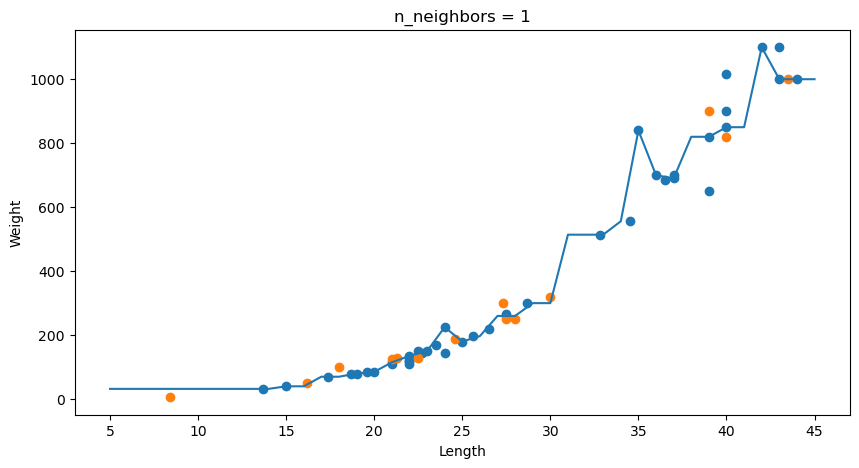

k ===> 3
Train Score: 0.9804899950518966
Test Score : 0.9746459963987609


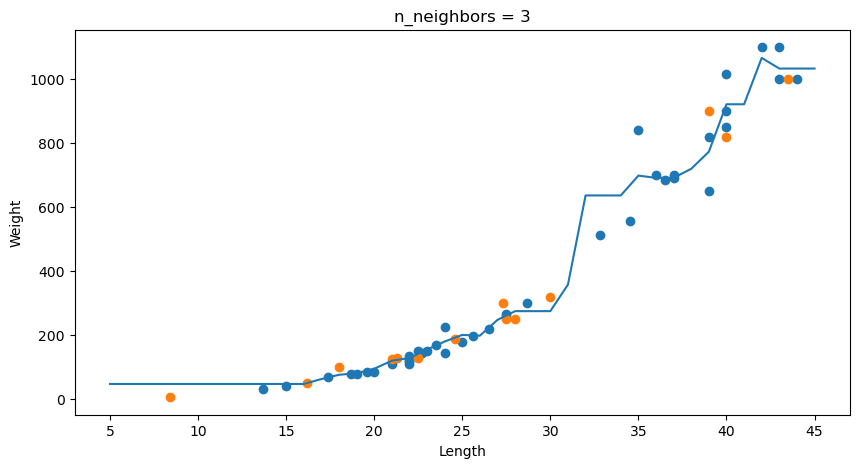

k ===> 5
Train Score: 0.9698823289099254
Test Score : 0.992809406101064


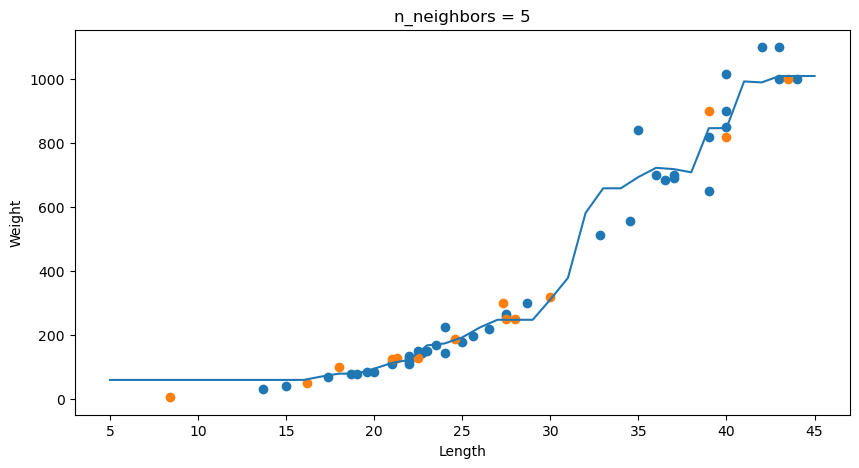

k ===> 7
Train Score: 0.9761170732051527
Test Score : 0.9781383949643516


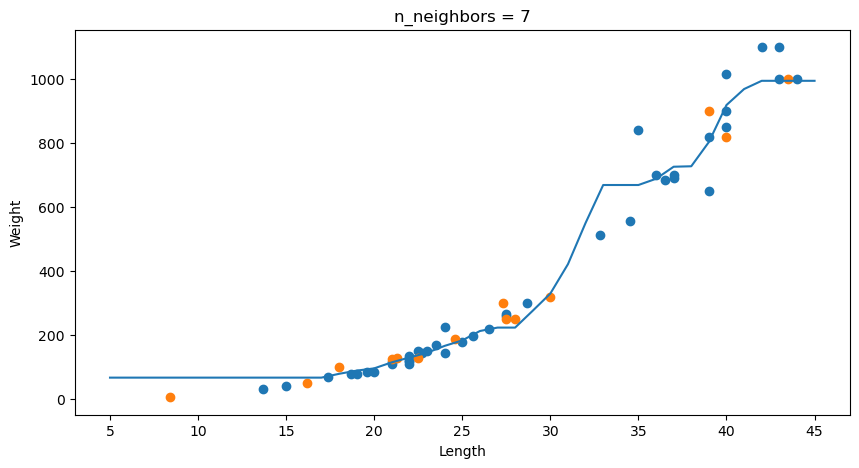

k ===> 9
Train Score: 0.9693310367551284
Test Score : 0.9692647749722698


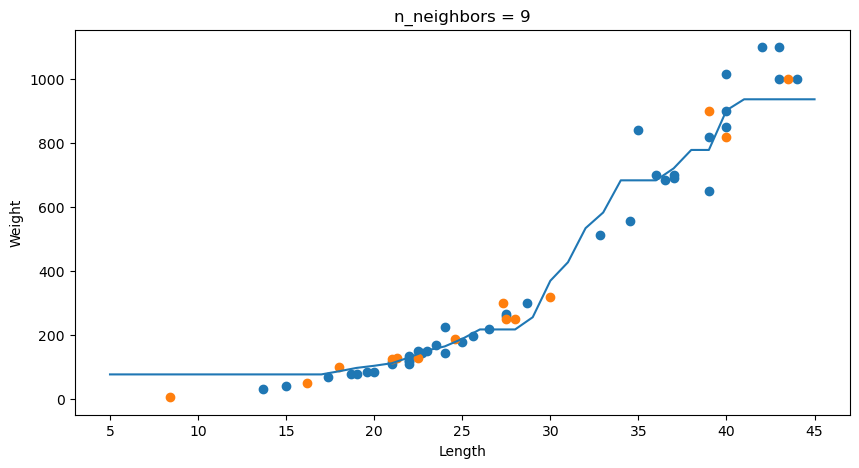

k ===> 11
Train Score: 0.9515761381539326
Test Score : 0.970279643030474


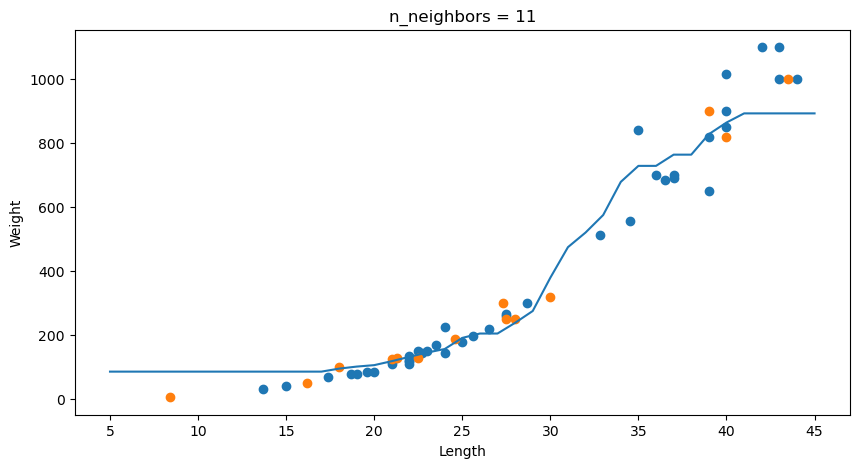

k ===> 13
Train Score: 0.9413423450130075
Test Score : 0.9639044643206888


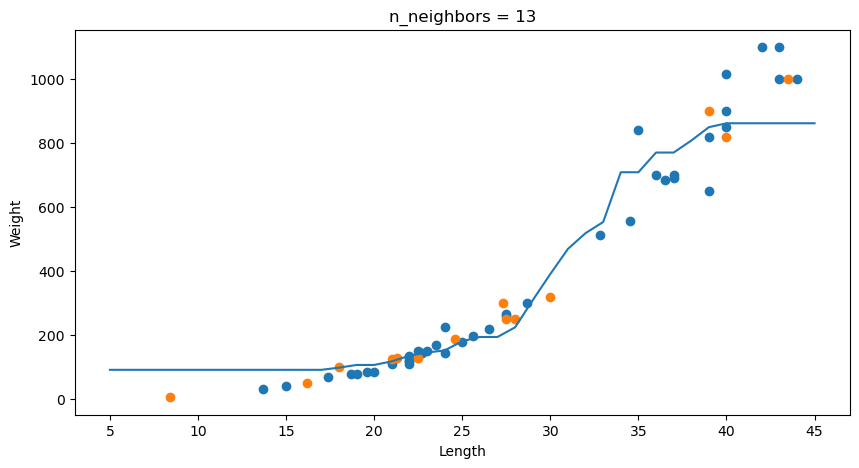

k ===> 15
Train Score: 0.930201118360776
Test Score : 0.9554827691127018


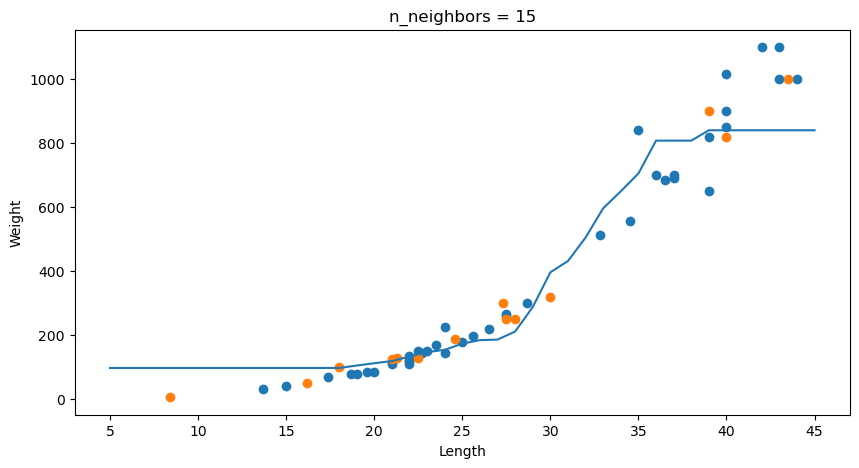

k ===> 17
Train Score: 0.9087778943199959
Test Score : 0.9314058693169347


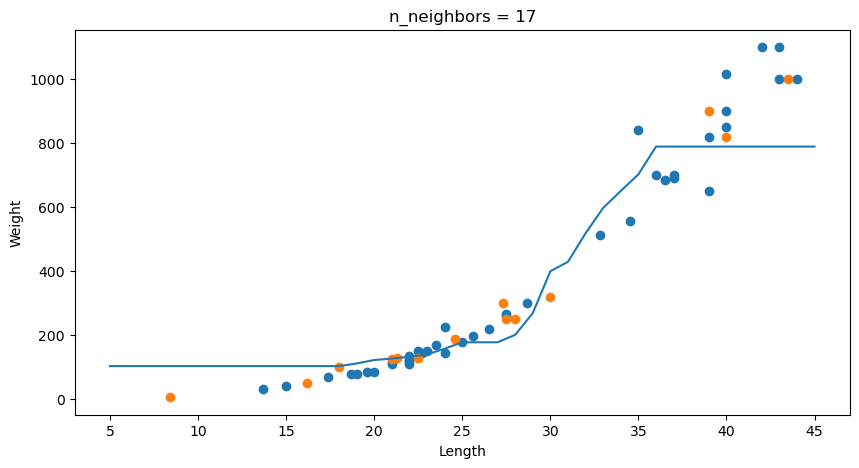

k ===> 19
Train Score: 0.8782082893573573
Test Score : 0.900993697623706


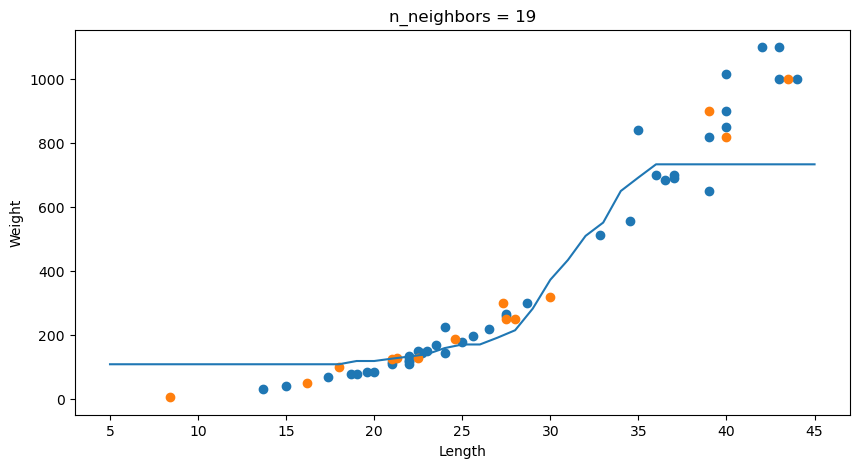

k ===> 21
Train Score: 0.8410922229110086
Test Score : 0.8596922255009882


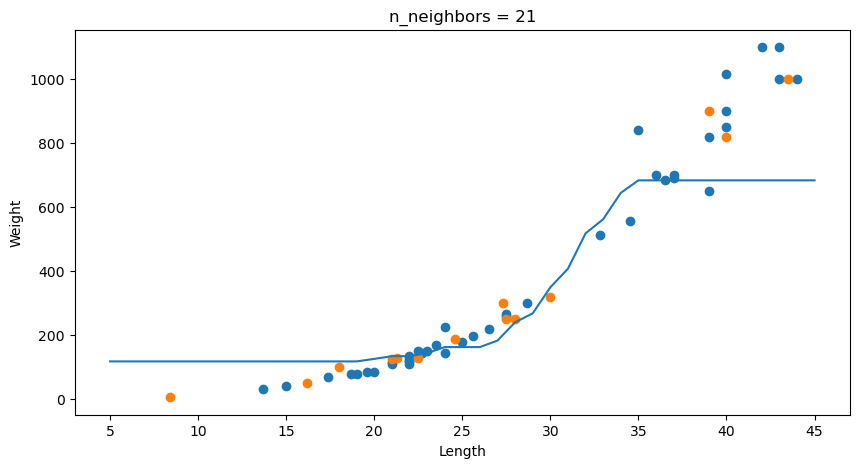

In [32]:
knr = KNeighborsRegressor()
# n_neighbors가 1, 3, 5, 7, 8, 11, 13, 15, 17, 19, 21

# 예측값의 x좌표
x = np.arange(5,45+1).reshape(-1, 1)

for n in range(1, 21+1, 2):
    # 모델 훈련
    knr.n_neighbors = n
    knr.fit(train_input, train_target)
    print("k ===>", n)
    print("Train Score:", knr.score(train_input, train_target))
    print("Test Score :", knr.score(test_input, test_target))
    print("=" * 20)

    # 지정한 범위 x에 대한 예측 구하기
    pred = knr.predict(x)

    # 훈련세트와 검증세트의 그래프
    plt.figure(figsize=(10,5))
    plt.scatter(train_input, train_target)
    plt.scatter(test_input, test_target)
    plt.plot(x, pred)
    plt.title(f'n_neighbors = {n}')
    plt.xlabel('Length')
    plt.ylabel('Weight')
    plt.show()

---
### 찾은 n_neighbors의 갯수로 모델 만들기

In [33]:
knr = KNeighborsRegressor(n_neighbors=9)
knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=9)

### 길이가 50cm인 생선의 무게 예측

In [34]:
knr.predict([[50]])

array([937.22222222])

### 기존 데이터로 무게 확인

In [35]:
for i,v in enumerate(train_target):
    if v == train_target.max():
        print(train_input[i], v)

[43.] 1100.0
[42.] 1100.0


#### 산점도로 이웃을 구해서 확인해 보자

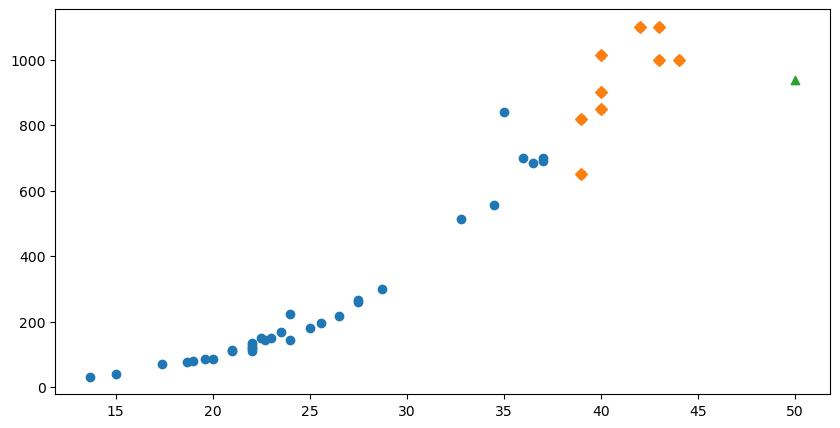

In [36]:
# 50cm 생선의 이웃을 구하자.
_, indexes = knr.kneighbors([[50]])

# 훈련세트의 산점도
plt.figure(figsize=(10,5))
plt.scatter(train_input, train_target)

# 훈련세트중 이웃 샘플만 그리자
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

# 50cm 생선 위치
plt.scatter(50, 937, marker='^')

plt.show()

In [37]:
# 이웃들의 평균값 계산
np.mean(train_target[indexes])

937.2222222222222

In [38]:
# 길이가 100cm인 생선의 무게 예측
knr.predict([[100]])

array([937.22222222])

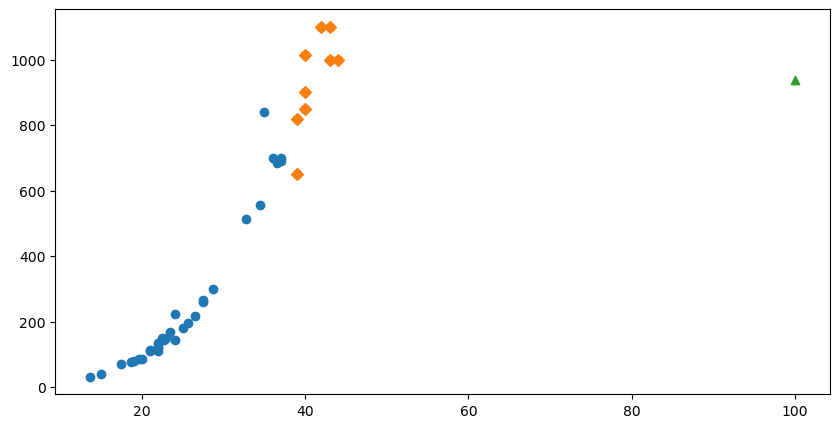

In [39]:
# 50cm 생선의 이웃을 구하자.
_, indexes = knr.kneighbors([[50]])

# 훈련세트의 산점도
plt.figure(figsize=(10,5))
plt.scatter(train_input, train_target)

# 훈련세트중 이웃 샘플만 그리자
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

# 50cm 생선 위치
plt.scatter(100, 937, marker='^')

plt.show()

> KNN Regression은 내주변 이웃의 값들의 평균을 구하는 것이므로 학습한 데이터의 범위를 벗어나게 되면 사용할 수 없다.

---
### 선형회귀(Linear Regression)
: 직선이나 곡선의 함수식(Y=aX+b)을 이용하여 구하는 방식으로 로지스틱 회귀분석이나 인공신경망의 기초가 되었다. 

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
lr = LinearRegression()
lr.fit(train_input, train_target)

LinearRegression()

In [42]:
# 50cm 생선의 예측
lr.predict([[50]])

array([1241.83860323])

In [43]:
lr.predict([[5]])

array([-513.93292014])

In [44]:
# Y=aX+b에서 기울기와 절편값 (Deep Learning에서는 weight와 Bias로 불림)
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535477


In [45]:
39.01714496 * 50 -709.0186449535477

1241.8386030464526

### 산점도 그리기

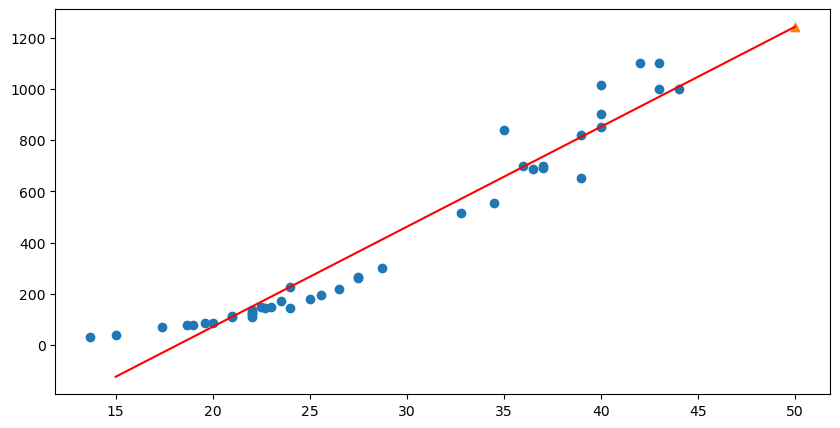

In [46]:
# 훈련세트의 산점도
plt.figure(figsize=(10,5))
plt.scatter(train_input, train_target)

# 15에서 50까지의 1차방정식 그래프
plt.plot(
    [15, 50],
    [15*lr.coef_+lr.intercept_, 50*lr.coef_+lr.intercept_],
    c='red'
)

# 50cm생선
plt.scatter(
    50,
    1241.8,
    marker='^'
)

plt.show()

> 산점도의 회귀선을 보니 길이가 작아지면 무게가 음수가 발생할 수 있다.   
절편이 음수이다.    

### 과대적합과 과소적합 확인

In [47]:
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.939846333997604
0.8247503123313558


---
### 특성공학(Feature Engineering)
##### 다항회귀 
- Y=aX^2 + bX + C
- 항이 여러개 있고 Feature가 하나인 것을 의미 
- Feature가 여러개인 회귀는 다중회귀 라고 한다.  

In [48]:
# Feature를 제곱한 컬럼을 생성하여 기존 컬럼에 붙인다.
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

In [49]:
print(train_poly.shape, test_poly.shape)

(42, 2) (14, 2)


In [50]:
train_poly

array([[ 384.16,   19.6 ],
       [ 484.  ,   22.  ],
       [ 349.69,   18.7 ],
       [ 302.76,   17.4 ],
       [1296.  ,   36.  ],
       [ 625.  ,   25.  ],
       [1600.  ,   40.  ],
       [1521.  ,   39.  ],
       [1849.  ,   43.  ],
       [ 484.  ,   22.  ],
       [ 400.  ,   20.  ],
       [ 484.  ,   22.  ],
       [ 576.  ,   24.  ],
       [ 756.25,   27.5 ],
       [1849.  ,   43.  ],
       [1600.  ,   40.  ],
       [ 576.  ,   24.  ],
       [ 441.  ,   21.  ],
       [ 756.25,   27.5 ],
       [1600.  ,   40.  ],
       [1075.84,   32.8 ],
       [ 702.25,   26.5 ],
       [1332.25,   36.5 ],
       [ 187.69,   13.7 ],
       [ 515.29,   22.7 ],
       [ 225.  ,   15.  ],
       [1369.  ,   37.  ],
       [1225.  ,   35.  ],
       [ 823.69,   28.7 ],
       [ 552.25,   23.5 ],
       [1521.  ,   39.  ],
       [ 441.  ,   21.  ],
       [ 529.  ,   23.  ],
       [ 484.  ,   22.  ],
       [1936.  ,   44.  ],
       [ 506.25,   22.5 ],
       [ 361.  ,   19.  ],
 

In [51]:
# Model 생성
lr = LinearRegression()
lr.fit(train_poly, train_target)

LinearRegression()

In [52]:
# 50cm생선 예측
lr.predict([[50**2, 50]])

array([1573.98423528])

In [53]:
# 기울기와 절편
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.05021078278304


In [54]:
1.01433211 * 50 **2 + -21.55792498 * 50 + 116.05021078278304

1573.984236782783

### 산점도로 확인하기

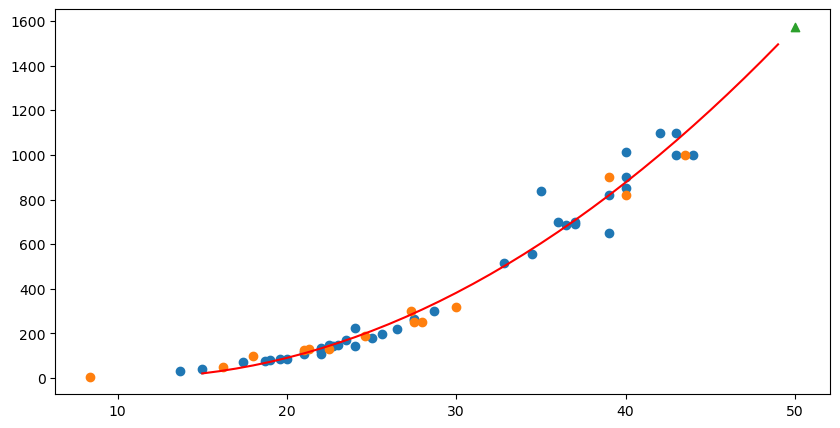

In [57]:
# 훈련세트의 산점도
plt.figure(figsize=(10,5))
plt.scatter(train_input, train_target)
plt.scatter(test_input, test_target)

# 구간별 직선을 그리기 위해 15에서 50까지 정수배열
point = np.arange(15, 50)

# 15에서 50까지의 2차방정식 그래프
plt.plot(
    point,
    1.01433211*point**2 -21.55792498*point + 116.05021078278304,
    c='red'
)

# 50cm생선
plt.scatter(
    50,
    1573.9,
    marker='^'
)

plt.show()

In [56]:
# 과대적합과 과소적합
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9706807451768623
0.9775935108325122


> 약간의 과소적합이 발생하지만 단순회귀 보다는 다항 회귀가 진전이 있었다.  